# Exploratory Data Analysis — Bank Marketing Dataset

## Objective
Understand the structure, quality, and distribution of the dataset before building predictive models.

Key aspects explored:

- Dataset structure
- Missing values and "unknown" categories
- Target distribution
- Preliminary risk of data leakage

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical variables:", len(num_cols))
print("Categorical variables:", len(cat_cols))

Numerical variables: 7
Categorical variables: 10


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
df.shape

(45211, 17)

In [ ]:
cardinality = df[cat_cols].nunique().sort_values(ascending=False)

cardinality

job          12
month        12
poutcome      4
education     4
marital       3
contact       3
loan          2
housing       2
default       2
y             2
dtype: int64

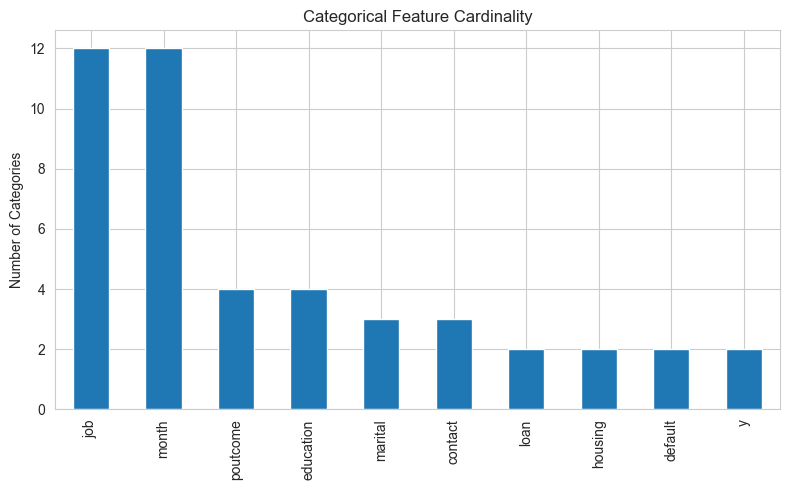

In [9]:
cardinality.plot(kind="bar")

plt.title("Categorical Feature Cardinality")
plt.ylabel("Number of Categories")

plt.tight_layout()

plt.savefig("../reports/figures/categorical_cardinality.png")

plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [12]:
unknown_rates = {}

for col in cat_cols:
    
    if "unknown" in df[col].unique():
        
        unknown_rates[col] = (df[col] == "unknown").mean()

unknown_rates = pd.Series(unknown_rates).sort_values(ascending=False)

unknown_rates

poutcome     0.817478
contact      0.287983
education    0.041074
job          0.006370
dtype: float64

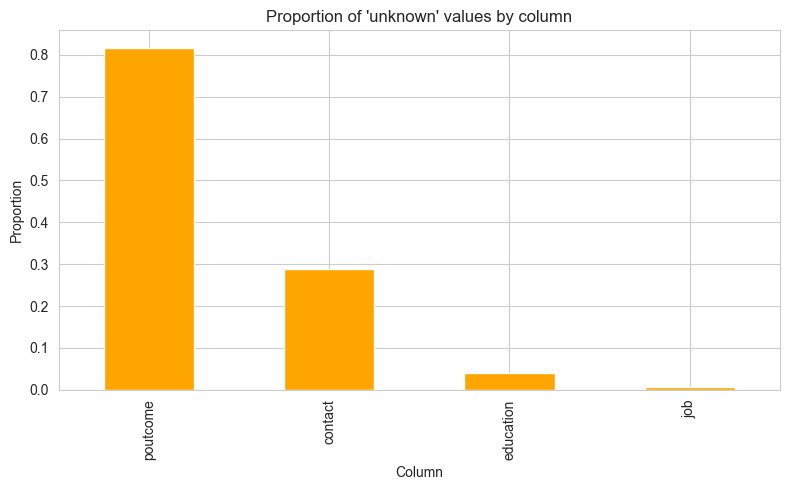

In [18]:
plt.figure(figsize=(8,5))

unknown_rates.plot(kind="bar", color="orange")

plt.title("Proportion of 'unknown' values by column")
plt.ylabel("Proportion")
plt.xlabel("Column")

plt.tight_layout()

plt.savefig("../reports/figures/unknown_rates.png")

plt.show()

In [14]:
df["y"].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

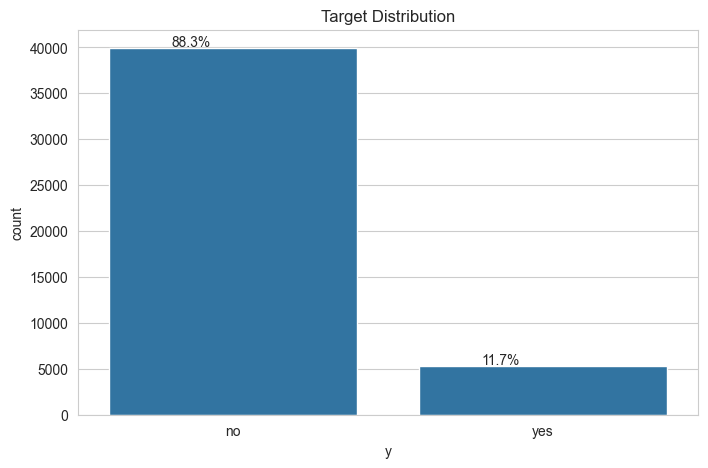

In [21]:
ax = sns.countplot(data=df, x="y")

total = len(df)

for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(percentage, (p.get_x()+0.2, p.get_height()+200))

plt.title("Target Distribution")

plt.show()

The dataset is imbalanced:

- ~88% no
- ~12% yes

Accuracy will not be used as the primary evaluation metric.

In [22]:
feature_audit = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.values,
    "unique_values": [df[col].nunique() for col in df.columns],
    "missing": [df[col].isnull().sum() for col in df.columns],
    "missing_%": [df[col].isnull().mean()*100 for col in df.columns]
})

feature_audit

,feature,dtype,unique_values,missing,missing_%
0,age,int64,77,0,0.0
1,job,object,12,0,0.0
2,marital,object,3,0,0.0
3,education,object,4,0,0.0
4,default,object,2,0,0.0
5,balance,int64,7168,0,0.0
6,housing,object,2,0,0.0
7,loan,object,2,0,0.0
8,contact,object,3,0,0.0
9,day,int64,31,0,0.0


In [17]:
leakage_audit = pd.DataFrame({

    "feature":[
        "age","job","marital","education","balance",
        "housing","loan","contact","day","month",
        "duration","campaign","pdays","previous","poutcome"
    ],
    
    "available_before_call":[
        True,True,True,True,True,
        True,True,True,True,True,
        False,True,True,True,True
    ]

})

leakage_audit

,feature,available_before_call
0,age,True
1,job,True
2,marital,True
3,education,True
4,balance,True
5,housing,True
6,loan,True
7,contact,True
8,day,True
9,month,True


The variable **duration** is only known after the call is completed.

Therefore it introduces **data leakage** if used for prediction.

Decision:

- Exclude duration from the production model
- Optionally evaluate its impact in a benchmark model

## Key Findings

Dataset size: 45,211 rows

No missing values detected.

However, several categorical variables contain "unknown" categories.

The target variable is imbalanced (~12% positive class).

The feature `duration` introduces data leakage and must be excluded in the production model.